## Formula

$$\phi_{\rm bar}(x,y,z)=\frac{GM_{\rm bar}}{2a_{\rm bar}}\ln\!\left(\frac{x-a_{\rm bar}+T_-}{x+a_{\rm bar}+T_+}\right)$$
$$\qquad T_\pm=\sqrt{(a_{\rm bar}\pm x)^2+y^2+\left(b_{\rm bar}+\sqrt{c_{\rm bar}^2+z^2}\right)^2}$$


$$ T_D=T_*(\frac{R_*}{R_D})^{1/2}$$

/var/folders/_b/cfj7mly10r9f3nkywrlqnl300000gn/T/ipykernel_7778/818815431.py:364: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rendered = Image.fromarray(rgba, mode="RGBA")


Input : $$T_{\pm}=\sqrt{(a_{\mathrm{bar}}\pm{}x)^2+y^2+\left(b_{\mathrm{bar}}+\sqrt{{c_{\mathrm{bar}}}^2+z^2}\right)^2}$$
Parsed: T_{\pm}=\sqrt{(a_{\mathrm{bar}}\pm{}x)^2+y^2+\left(b_{\mathrm{bar}}+\sqrt{{c_{\mathrm{bar}}}^2+z^2}\right)^2}
Tokens: ['T', '_', '{', '\\pm', '}', '=', '\\sqrt', '{', '(', 'a', '_', '{', '\\mathrm', '{', 'b', 'a', 'r', '}', '}', '\\pm', '{', '}', 'x', ')', '^', '2', '+', 'y', '^', '2', '+', '\\left', '(', 'b', '_', '{', '\\mathrm', '{', 'b', 'a', 'r', '}', '}', '+', '\\sqrt', '{', '{', 'c', '_', '{', '\\mathrm', '{', 'b', 'a', 'r', '}', '}', '}', '^', '2', '+', 'z', '^', '2', '}', '\\right', ')', '^', '2', '}']
Steps : 24
Canvas: 2318 x 355
Saved: /Users/mloktionov/Projects/IncusLuminis/products/nebulacast/nebulacast-content/content/papers/shared/formula_2.gif


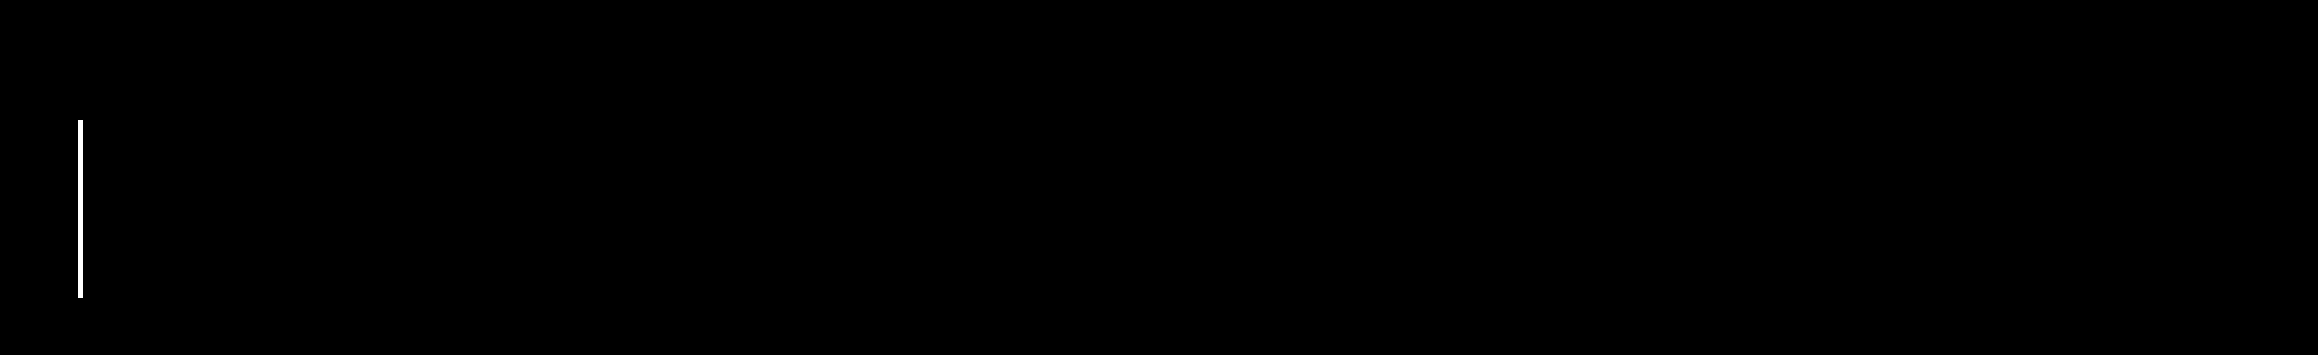

In [14]:
from pathlib import Path
from functools import lru_cache
import re

import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display, Image as IPyImage

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt  # оставлено, чтобы не менять структуру импорта
from matplotlib.mathtext import MathTextParser
from matplotlib.font_manager import FontProperties


# =========================
# Input
# =========================
FORMULA = r"$$T_{\pm}=\sqrt{(a_{\mathrm{bar}}\pm{}x)^2+y^2+\left(b_{\mathrm{bar}}+\sqrt{{c_{\mathrm{bar}}}^2+z^2}\right)^2}$$"

# =========================
# Config
# =========================
OUTPUT_GIF = "formula_2.gif"

BG_COLOR = "black"
FG_COLOR = "white"
# "#0EDA41" # - green
# "#88CEFC" - blue

FONT_SIZE_PT = 34
DPI = 200


FRAME_DURATION_MS = 180
REVEAL_FRAMES_PER_STEP = 8
FINAL_STILL_MS = 1200
CURSOR_BLINK_MS = 220
FINAL_CURSOR_BLINKS = 5
REVEAL_TOTAL_MS = 2400
REVEAL_FPS = 30
EDGE_SOFTNESS_PX = 24

# outer canvas
MIN_WIDTH = 1000
MIN_HEIGHT = 280
OUTER_PAD_X = 40
OUTER_PAD_Y = 30

# formula box
FORMULA_BOX_PAD_X = 30
FORMULA_BOX_PAD_Y = 24

# very important: extra transparent padding around every rendered formula
INTERNAL_RENDER_PAD_PX = 32
TIGHT_PAD_INCHES = 0.08  # оставлено для совместимости, здесь больше не используется напрямую

# cursor
CURSOR_WIDTH = 4
CURSOR_GAP = 8
CURSOR_HEIGHT_RATIO = 0.72
CURSOR_BOTTOM_PAD = 4

CURSOR_ENABLED = True
CURSOR_BLINK_MS = 400
FINAL_CURSOR_BLINKS = 6

# =========================
# Normalize
# =========================
def normalize_formula_input(expr: str) -> str:
    if not isinstance(expr, str):
        raise TypeError("FORMULA must be a string.")

    s = expr.strip()
    pairs = [
        (r"$$", r"$$"),
        (r"\[", r"\]"),
        (r"\(", r"\)"),
        (r"$", r"$"),
    ]

    for left, right in pairs:
        if s.startswith(left) and s.endswith(right) and len(s) >= len(left) + len(right):
            inner = s[len(left): len(s) - len(right)].strip()
            if not inner:
                raise ValueError("Formula inside delimiters is empty.")
            return inner

    if not s:
        raise ValueError("FORMULA is empty.")

    return s


# =========================
# Tokenizer
# =========================
def tokenize_math(expr: str) -> list[str]:
    pattern = r"""
        (\\[A-Za-z]+)           |   # commands
        (\\.)                   |   # escaped char
        (\s+)                   |   # spaces
        ([{}_^])                |   # structural chars
        ([0-9]+(?:\.[0-9]+)?)   |   # numbers
        ([A-Za-z])              |   # letters
        (.)                         # fallback
    """
    tokens = []
    for match in re.finditer(pattern, expr, re.VERBOSE):
        token = next(g for g in match.groups() if g is not None)
        if token.isspace():
            continue
        tokens.append(token)
    return tokens


# =========================
# AST
# =========================
class Node:
    def full(self) -> str:
        raise NotImplementedError

    def steps(self) -> list[str]:
        raise NotImplementedError

    def content_full(self) -> str:
        return self.full()

    def content_steps(self) -> list[str]:
        return self.steps()


class Literal(Node):
    def __init__(self, value: str):
        self.value = value

    def full(self) -> str:
        return self.value

    def steps(self) -> list[str]:
        return [self.value]


class Sequence(Node):
    def __init__(self, items: list["Node"]):
        self.items = items

    def full(self) -> str:
        return "".join(item.full() for item in self.items)

    def steps(self) -> list[str]:
        out = []
        prefix = ""
        for item in self.items:
            for s in item.steps():
                candidate = prefix + s
                if can_render(candidate):
                    out.append(candidate)
            prefix += item.full()
        return dedupe(out)


class Group(Node):
    def __init__(self, inner: "Node"):
        self.inner = inner

    def full(self) -> str:
        return "{" + self.inner.full() + "}"

    def steps(self) -> list[str]:
        return ["{" + s + "}" for s in self.inner.steps()]

    def content_full(self) -> str:
        return self.inner.full()

    def content_steps(self) -> list[str]:
        return self.inner.steps()


class Scripted(Node):
    def __init__(self, base: "Node", scripts: list[tuple[str, "Node"]]):
        self.base = base
        self.scripts = scripts

    def full(self) -> str:
        s = self.base.full()
        for op, arg in self.scripts:
            s += op + "{" + arg.content_full() + "}"
        return s

    def steps(self) -> list[str]:
        out = []
        current = self.base.full()

        for s in self.base.steps():
            if can_render(s):
                out.append(s)

        for op, arg in self.scripts:
            placeholder = current + op + r"{\;}"
            if can_render(placeholder):
                out.append(placeholder)

            for s in arg.content_steps():
                candidate = current + op + "{" + s + "}"
                if can_render(candidate):
                    out.append(candidate)

            current = current + op + "{" + arg.content_full() + "}"

        return dedupe(out)


class Sqrt(Node):
    def __init__(self, arg: "Node"):
        self.arg = arg

    def full(self) -> str:
        return r"\sqrt{" + self.arg.content_full() + "}"

    def steps(self) -> list[str]:
        out = []
        start = r"\sqrt{\;}"
        if can_render(start):
            out.append(start)

        for s in self.arg.content_steps():
            candidate = r"\sqrt{" + s + "}"
            if can_render(candidate):
                out.append(candidate)

        return dedupe(out)


class Frac(Node):
    def __init__(self, num: "Node", den: "Node"):
        self.num = num
        self.den = den

    def full(self) -> str:
        return r"\frac{" + self.num.content_full() + "}{" + self.den.content_full() + "}"

    def steps(self) -> list[str]:
        out = []

        for s in self.num.content_steps():
            candidate = r"\frac{" + s + r"}{\;}"
            if can_render(candidate):
                out.append(candidate)

        num_full = self.num.content_full()

        for s in self.den.content_steps():
            candidate = r"\frac{" + num_full + "}{" + s + "}"
            if can_render(candidate):
                out.append(candidate)

        return dedupe(out)


def dedupe(items: list[str]) -> list[str]:
    out = []
    seen = set()
    for x in items:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out


# =========================
# Parser
# =========================
def parse_expression(tokens: list[str], i: int = 0) -> tuple[Node, int]:
    items = []
    while i < len(tokens) and tokens[i] != "}":
        node, i = parse_atom_with_scripts(tokens, i)
        items.append(node)
    return Sequence(items), i


def parse_atom_with_scripts(tokens: list[str], i: int) -> tuple[Node, int]:
    node, i = parse_atom(tokens, i)

    scripts = []
    while i < len(tokens) and tokens[i] in ("_", "^"):
        op = tokens[i]
        i += 1
        arg, i = parse_required_arg(tokens, i)
        scripts.append((op, arg))

    if scripts:
        return Scripted(node, scripts), i
    return node, i


def parse_required_arg(tokens: list[str], i: int) -> tuple[Node, int]:
    if i >= len(tokens):
        raise ValueError("Unexpected end of formula while parsing argument.")
    return parse_atom_with_scripts(tokens, i)


def parse_atom(tokens: list[str], i: int) -> tuple[Node, int]:
    if i >= len(tokens):
        raise ValueError("Unexpected end of formula.")

    tok = tokens[i]

    if tok == "{":
        inner, j = parse_expression(tokens, i + 1)
        if j >= len(tokens) or tokens[j] != "}":
            raise ValueError("Unbalanced braces in formula.")
        return Group(inner), j + 1

    if tok == r"\sqrt":
        arg, j = parse_required_arg(tokens, i + 1)
        return Sqrt(arg), j

    if tok == r"\frac":
        num, j = parse_required_arg(tokens, i + 1)
        den, k = parse_required_arg(tokens, j)
        return Frac(num, den), k

    return Literal(tok), i + 1


# =========================
# Renderer
# =========================
NORMALIZED_FORMULA = normalize_formula_input(FORMULA)

_PARSER = MathTextParser("agg")
_FONT_PROP = FontProperties(size=FONT_SIZE_PT)


@lru_cache(maxsize=512)
def _render_formula_metrics(math_expr: str):
    parsed = _PARSER.parse(
        f"${math_expr}$",
        dpi=DPI,
        prop=_FONT_PROP,
    )

    alpha = np.asarray(parsed.image)
    h, w = alpha.shape

    fg_rgb = Image.new("RGB", (1, 1), FG_COLOR).getpixel((0, 0))

    rgba = np.zeros(
        (h + 2 * INTERNAL_RENDER_PAD_PX, w + 2 * INTERNAL_RENDER_PAD_PX, 4),
        dtype=np.uint8,
    )
    rgba[..., 0] = fg_rgb[0]
    rgba[..., 1] = fg_rgb[1]
    rgba[..., 2] = fg_rgb[2]
    rgba[
        INTERNAL_RENDER_PAD_PX:INTERNAL_RENDER_PAD_PX + h,
        INTERNAL_RENDER_PAD_PX:INTERNAL_RENDER_PAD_PX + w,
        3,
    ] = alpha

    rendered = Image.fromarray(rgba, mode="RGBA")

    width = rendered.width
    height = rendered.height
    depth = int(np.ceil(parsed.depth)) + INTERNAL_RENDER_PAD_PX

    return rendered, width, height, depth


@lru_cache(maxsize=512)
def render_formula_rgba(math_expr: str) -> Image.Image:
    rendered, _, _, _ = _render_formula_metrics(math_expr)
    return rendered


def can_render(math_expr: str) -> bool:
    try:
        _ = render_formula_rgba(math_expr)
        return True
    except Exception:
        return False


FULL_RENDER = render_formula_rgba(NORMALIZED_FORMULA)
_, FULL_W, FULL_H, FULL_DEPTH = _render_formula_metrics(NORMALIZED_FORMULA)

CURSOR_HEIGHT_PX = max(12, int(FULL_H * CURSOR_HEIGHT_RATIO))

FORMULA_BOX_W = FULL_W + 2 * FORMULA_BOX_PAD_X
FORMULA_BOX_H = FULL_H + 2 * FORMULA_BOX_PAD_Y

WIDTH = max(
    MIN_WIDTH,
    FORMULA_BOX_W + CURSOR_GAP + CURSOR_WIDTH + 2 * OUTER_PAD_X
)

HEIGHT = max(
    MIN_HEIGHT,
    FORMULA_BOX_H + 2 * OUTER_PAD_Y
)

FORMULA_BOX_X = (WIDTH - (FORMULA_BOX_W + CURSOR_GAP + CURSOR_WIDTH)) // 2
FORMULA_BOX_Y = (HEIGHT - FORMULA_BOX_H) // 2

FULL_X = FORMULA_BOX_X + FORMULA_BOX_PAD_X
FULL_Y = FORMULA_BOX_Y + FORMULA_BOX_PAD_Y

# фиксированная baseline для всей анимации
BASELINE_BOX_BOTTOM_Y = FULL_Y + FULL_H
BASELINE_Y = BASELINE_BOX_BOTTOM_Y - FULL_DEPTH


def draw_cursor(base: Image.Image, current_render_w: int, current_x: int):
    draw = ImageDraw.Draw(base)

    x0 = current_x + current_render_w + CURSOR_GAP
    x1 = x0 + CURSOR_WIDTH

    y1 = BASELINE_BOX_BOTTOM_Y - CURSOR_BOTTOM_PAD
    y0 = y1 - CURSOR_HEIGHT_PX

    draw.rectangle([x0, y0, x1, y1], fill=FG_COLOR)


def make_frame(reveal_ratio: float = 1.0, cursor_visible: bool = False) -> Image.Image:
    base = Image.new("RGBA", (WIDTH, HEIGHT), BG_COLOR)

    full_render = render_formula_rgba(NORMALIZED_FORMULA)

    reveal_ratio = max(0.0, min(1.0, reveal_ratio))
    visible_w = int(full_render.width * reveal_ratio)

    if visible_w > 0:
        mask = Image.new("L", full_render.size, 0)
        mask_draw = ImageDraw.Draw(mask)

        hard_w = max(0, visible_w - EDGE_SOFTNESS_PX)
        if hard_w > 0:
            mask_draw.rectangle([0, 0, hard_w, full_render.height], fill=255)

        if visible_w > hard_w:
            for x in range(hard_w, min(visible_w, full_render.width)):
                alpha = int(255 * (x - hard_w) / max(1, visible_w - hard_w))
                mask_draw.line([(x, 0), (x, full_render.height)], fill=alpha)

        visible = Image.new("RGBA", full_render.size, (0, 0, 0, 0))
        visible.paste(full_render, (0, 0), mask)

        base.alpha_composite(visible, (FULL_X, FULL_Y))

    # ===== КУРСОР =====
    if cursor_visible and CURSOR_ENABLED:
        draw = ImageDraw.Draw(base)

        x0 = FULL_X + visible_w + CURSOR_GAP
        x1 = x0 + CURSOR_WIDTH

        y1 = FULL_Y + FULL_H - CURSOR_BOTTOM_PAD
        y0 = y1 - CURSOR_HEIGHT_PX

        draw.rectangle([x0, y0, x1, y1], fill=FG_COLOR)

    return base.convert("RGB")


# =========================
# Build steps
# =========================
tokens = tokenize_math(NORMALIZED_FORMULA)
ast, pos = parse_expression(tokens, 0)
if pos != len(tokens):
    raise ValueError("Parser did not consume the whole formula.")

steps = ast.steps()
if not steps or steps[-1] != ast.full():
    if can_render(ast.full()):
        steps.append(ast.full())
    else:
        raise ValueError("Final formula cannot be rendered.")


# =========================
# Animation
# =========================
def build_frames(formula_steps: list[str], final_formula: str):
    frames = []
    durations = []

    total_frames = max(2, int(REVEAL_TOTAL_MS / 1000 * REVEAL_FPS))
    per_frame_duration = max(20, int(REVEAL_TOTAL_MS / total_frames))

    # анимация появления
    for i in range(total_frames):
        t = i / (total_frames - 1)
        reveal_ratio = t * t * t * (t * (t * 6 - 15) + 10)

        frames.append(make_frame(reveal_ratio, True))
        durations.append(per_frame_duration)

    # финальное мигание
    for _ in range(FINAL_CURSOR_BLINKS):
        frames.append(make_frame(1.0, True))
        durations.append(CURSOR_BLINK_MS)

        frames.append(make_frame(1.0, False))
        durations.append(CURSOR_BLINK_MS)

    frames.append(make_frame(1.0, False))
    durations.append(FINAL_STILL_MS)

    return frames, durations
    
    
def save_gif(frames, durations, output_path):
    out = Path(output_path).resolve()
    frames[0].save(
        out,
        save_all=True,
        append_images=frames[1:],
        optimize=False,
        duration=durations,
        loop=0,
    )
    return out


frames, durations = build_frames(steps, ast.full())
gif_path = save_gif(frames, durations, OUTPUT_GIF)

print("Input :", FORMULA)
print("Parsed:", NORMALIZED_FORMULA)
print("Tokens:", tokens)
print("Steps :", len(steps))
print("Canvas:", WIDTH, "x", HEIGHT)
print(f"Saved: {gif_path}")
display(IPyImage(filename=str(gif_path)))